In [1]:
import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mcd_menu_scrubbed.csv")

df.head()

,category,product_name,calories,fat_g,carbohydrates_g,proteins_g
0,Breakfast,Egg McMuffin,300,13.0,31.0,17.0
1,Breakfast,Egg White Delight,250,8.0,30.0,18.0
2,Breakfast,Sausage McMuffin,370,23.0,29.0,14.0
3,Breakfast,Sausage McMuffin with Egg,450,28.0,30.0,21.0
4,Breakfast,Sausage McMuffin with Egg Whites,400,23.0,30.0,21.0


In [5]:
print(df.columns.tolist())

['category', 'product_name', 'calories', 'fat_g', 'carbohydrates_g', 'proteins_g']


In [8]:
print([col for col in df.columns])

['category', 'product_name', 'calories', 'fat_g', 'carbohydrates_g', 'proteins_g']


In [9]:
df.columns = df.columns.str.strip()

In [12]:
print(df.columns)

for col in df.columns:
    print(f"'{col}'")

Index(['category', 'product_name', 'calories', 'fat_g', 'carbohydrates_g',
       'proteins_g'],
      dtype='str')
'category'
'product_name'
'calories'
'fat_g'
'carbohydrates_g'
'proteins_g'


In [17]:
missing = [col for col in numeric_cols if col not in df.columns]
print("Missing columns:", missing)

Missing columns: ['total_fat', 'carbs', 'protein']


In [20]:
print("X_text exists:", "X_text" in globals())
print("X_numeric exists:", "X_numeric" in globals())

X_text exists: False
X_numeric exists: False


In [23]:
print(df.head())
print(df.columns)

    category                      product_name  calories  fat_g  \
0  Breakfast                      Egg McMuffin       300   13.0   
1  Breakfast                 Egg White Delight       250    8.0   
2  Breakfast                  Sausage McMuffin       370   23.0   
3  Breakfast         Sausage McMuffin with Egg       450   28.0   
4  Breakfast  Sausage McMuffin with Egg Whites       400   23.0   

   carbohydrates_g  proteins_g  
0             31.0        17.0  
1             30.0        18.0  
2             29.0        14.0  
3             30.0        21.0  
4             30.0        21.0  
Index(['category', 'product_name', 'calories', 'fat_g', 'carbohydrates_g',
       'proteins_g'],
      dtype='str')


In [25]:

df.head()

,category,product_name,calories,fat_g,carbohydrates_g,proteins_g
0,Breakfast,Egg McMuffin,300,13.0,31.0,17.0
1,Breakfast,Egg White Delight,250,8.0,30.0,18.0
2,Breakfast,Sausage McMuffin,370,23.0,29.0,14.0
3,Breakfast,Sausage McMuffin with Egg,450,28.0,30.0,21.0
4,Breakfast,Sausage McMuffin with Egg Whites,400,23.0,30.0,21.0


In [26]:
print(df.columns)

Index(['category', 'product_name', 'calories', 'fat_g', 'carbohydrates_g',
       'proteins_g'],
      dtype='str')


In [31]:
print(df.columns.tolist())

['category', 'product_name', 'calories', 'fat_g', 'carbohydrates_g', 'proteins_g']


Columns: ['category', 'product_name', 'calories', 'fat_g', 'carbohydrates_g', 'proteins_g', 'menu_item']
Cleaned Columns: ['category', 'product_name', 'calories', 'fat_g', 'carbohydrates_g', 'proteins_g', 'menu_item']


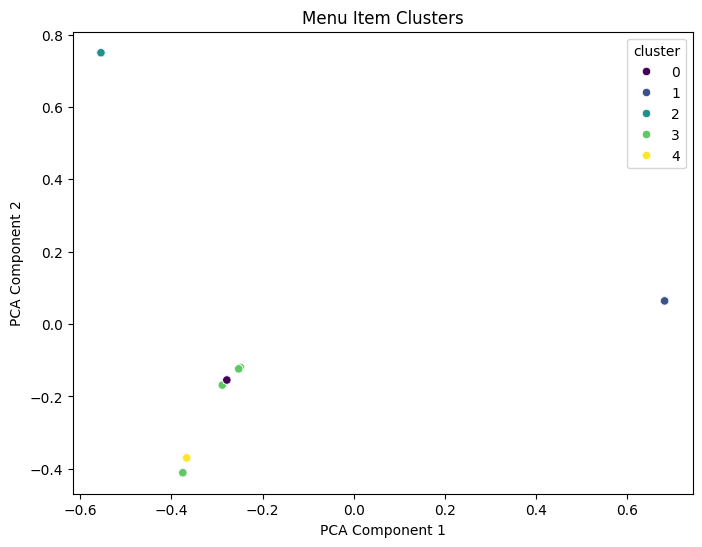

In [34]:
# Imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 🔍 Step 0: Inspect columns
print("Columns:", df.columns.tolist())

# ✅ Step 1: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("Cleaned Columns:", df.columns.tolist())

# ✅ Step 2: Identify text columns
text_col_1 = None
text_col_2 = None

possible_name_cols = ["name", "item_name", "title"]
possible_desc_cols = ["description", "desc", "item_description"]

for col in df.columns:
    if col in possible_name_cols:
        text_col_1 = col
    if col in possible_desc_cols:
        text_col_2 = col

if text_col_1 is None:
    text_col_1 = df.columns[0]

if text_col_2 is not None:
    df["menu_item"] = df[text_col_1].fillna('') + " " + df[text_col_2].fillna('')
else:
    df["menu_item"] = df[text_col_1].fillna('')

# ✅ Step 3: TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["menu_item"])

# ✅ Step 4: CREATE CLUSTERS (THIS WAS MISSING)
kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# ✅ Step 5: PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

# ✅ Step 6: Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["cluster"],
    palette="viridis"
)

plt.title("Menu Item Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()